## data checking

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

data = pd.read_csv('./Linear Regression Design.csv')

data.sample(10)

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
16852,2017,FORD,F-150 4X4 (Payload Pkg),PICKUP TRUCK - STANDARD,3.5,6,AS10,X,14.0,11.0,12.7,22,298
8491,2009,KIA,SEDONA,MINIVAN,3.8,6,AS5,X,13.2,8.8,11.2,25,258
2127,2003,BMW,525i,COMPACT,2.5,6,M5,Z,11.6,7.4,9.7,29,223
3129,2004,DODGE,CARAVAN C/V,MINIVAN,3.3,6,A4,X,12.2,8.2,10.4,27,239
21748,2022,Cadillac,CT4-V,Compact,2.7,4,AS10,Z,11.9,8.2,10.2,28,239
4213,2005,GMC,H15 SAVANA PASSENGER AWD,VAN - PASSENGER,5.3,8,A4,X,17.0,13.1,15.2,19,350
5004,2006,CHEVROLET,K1500 SUBURBAN FFV 4X4,SUV,5.3,8,A4,E,22.9,16.5,20.0,14,320
5467,2006,MERCEDES-BENZ,SLK55 AMG #,TWO-SEATER,5.4,8,AS7,Z,15.0,9.8,12.7,22,292
20312,2020,Lexus,RC 300 AWD,Subcompact,3.5,6,AS6,Z,13.1,9.8,11.2,25,262
8594,2009,MERCEDES-BENZ,CLK 63 AMG,SUBCOMPACT,6.2,8,AS7,Z,18.0,10.6,14.7,19,338


In [24]:
Dimension = data.shape
print("total data:", Dimension)

data.info()
data.isnull().sum()
data[data.duplicated()]

total data: (22556, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
378,2000,LAND ROVER,DISCOVERY SERIES II 4X4,SUV,4.0,8,A4,Z,17.7,12.7,15.4,18,354


In [25]:
# Create target variable: Fuel Efficiency in km/L
data['FUEL_EFFICIENCY'] = 100 / data['COMB (L/100 km)']

# Drop unnecessary columns
columns_to_drop = [
    'FUEL CONSUMPTION',  # City fuel consumption
    'HWY (L/100 km)',    # Highway fuel consumption
    'COMB (L/100 km)',  # Combined fuel consumption (used to create target)
    'COMB (mpg)',       # Combined fuel consumption in mpg (redundant with target)
    'MODEL'             # Too many unique values, could cause overfitting
]

data = data.drop(columns=columns_to_drop)


print("\nColumns after dropping:")
print(data.columns.tolist())

# Check the cleaned dataset
print("\nCleaned Dataset Info:")
data.info()

# Display the first few rows of the cleaned dataset
print("\nFirst 5 rows of cleaned dataset:")
print(data.head())


Columns after dropping:
['YEAR', 'MAKE', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'EMISSIONS', 'FUEL_EFFICIENCY']

Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             22556 non-null  int64  
 1   MAKE             22556 non-null  object 
 2   VEHICLE CLASS    22556 non-null  object 
 3   ENGINE SIZE      22556 non-null  float64
 4   CYLINDERS        22556 non-null  int64  
 5   TRANSMISSION     22556 non-null  object 
 6   FUEL             22556 non-null  object 
 7   EMISSIONS        22556 non-null  int64  
 8   FUEL_EFFICIENCY  22556 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 1.5+ MB

First 5 rows of cleaned dataset:
   YEAR   MAKE VEHICLE CLASS  ENGINE SIZE  CYLINDERS TRANSMISSION FUEL  \
0  2000  ACURA       COMPACT          1.6         

In [26]:
# save data to csv
data.to_csv('cleaned_data_linear_regression.csv', index=False)

## data cleaning

In [27]:
data = pd.read_csv("cleaned_data_linear_regression.csv")

# Check the current state of the data
print("Dataset shape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nFirst 5 rows:")
print(data.head())

# Check for missing values again
print("\nMissing values:")
print(data.isnull().sum())

# Check unique values in categorical columns
print("\nUnique values in categorical columns:")
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()} unique values")
    if col == 'TRANSMISSION':
        print(f"Sample values: {data[col].unique()[:10]}") 

# Process the TRANSMISSION column
def process_transmission(trans):
    trans = str(trans)
    
    gears = ''.join(filter(str.isdigit, trans))
    if gears:
        gears = int(gears)
    else:
        gears = 0
    
    # Extract transmission type
    if 'A' in trans and 'S' in trans:
        trans_type = 'Automatic with select shift'
    elif 'A' in trans and 'M' in trans:
        trans_type = 'Automated manual'
    elif 'A' in trans:
        trans_type = 'Automatic'
    elif 'M' in trans:
        trans_type = 'Manual'
    elif 'AV' in trans:
        trans_type = 'Continuously variable'
    else:
        trans_type = 'Unknown'
    
    return pd.Series([gears, trans_type])

data[['GEARS', 'TRANS_TYPE']] = data['TRANSMISSION'].apply(process_transmission)

# Drop the original TRANSMISSION column
data = data.drop(columns=['TRANSMISSION'])

# Check the processed data
print("\nAfter processing TRANSMISSION:")
print(data.head())

# Check unique values in the new TRANS_TYPE column
print("\nUnique values in TRANS_TYPE:")
print(data['TRANS_TYPE'].value_counts())

# Check unique values in GEARS
print("\nUnique values in GEARS:")
print(data['GEARS'].value_counts().sort_index())

# Handle any remaining missing values (if any)
print("\nMissing values after processing:")
print(data.isnull().sum())

# If there are missing values, we'll fill them
if data.isnull().sum().sum() > 0:
    numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if col != 'FUEL_EFFICIENCY':
            data[col].fillna(data[col].median(), inplace=True)
    
    # For categorical columns, fill with mode
    categorical_cols = data.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        data[col].fillna(data[col].mode()[0], inplace=True)

# Check for outliers in numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col != 'FUEL_EFFICIENCY']  # Exclude target

print("\nChecking for outliers in numerical columns:")
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%)")

Dataset shape: (22556, 9)

Columns: ['YEAR', 'MAKE', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'EMISSIONS', 'FUEL_EFFICIENCY']

First 5 rows:
   YEAR   MAKE VEHICLE CLASS  ENGINE SIZE  CYLINDERS TRANSMISSION FUEL  \
0  2000  ACURA       COMPACT          1.6          4           A4    X   
1  2000  ACURA       COMPACT          1.6          4           M5    X   
2  2000  ACURA      MID-SIZE          3.2          6          AS5    Z   
3  2000  ACURA      MID-SIZE          3.5          6           A4    Z   
4  2000  ACURA    SUBCOMPACT          1.8          4           A4    X   

   EMISSIONS  FUEL_EFFICIENCY  
0        186        12.345679  
1        175        13.157895  
2        230        10.000000  
3        264         8.695652  
4        198        11.627907  

Missing values:
YEAR               0
MAKE               0
VEHICLE CLASS      0
ENGINE SIZE        0
CYLINDERS          0
TRANSMISSION       0
FUEL               0
EMISSIONS          0
FUEL_EFFI

## visualize data

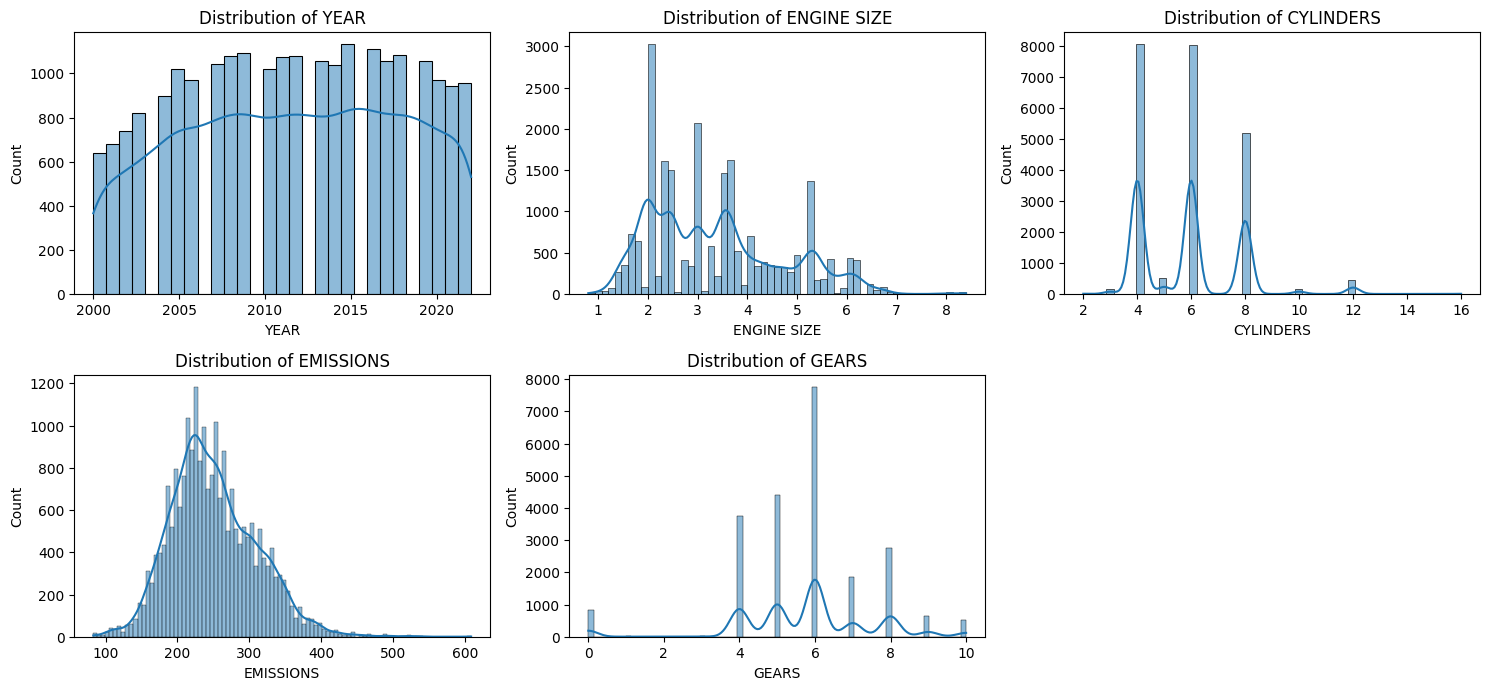

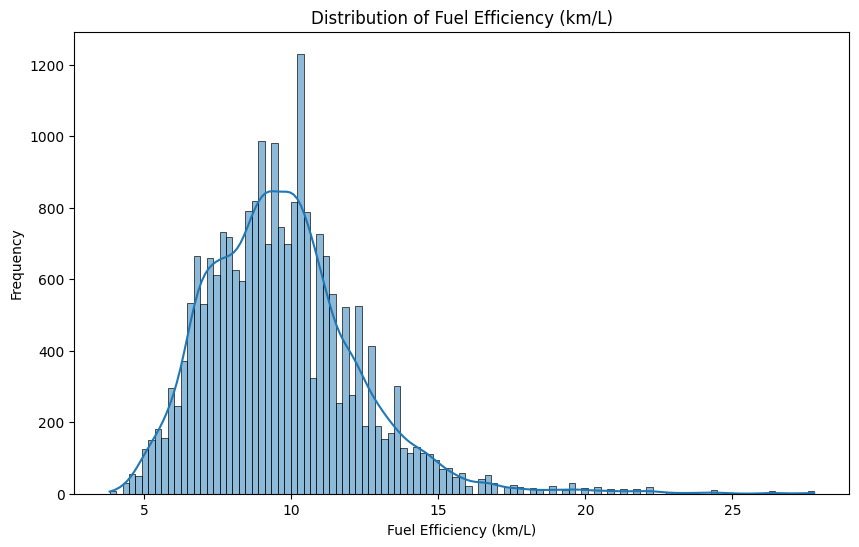

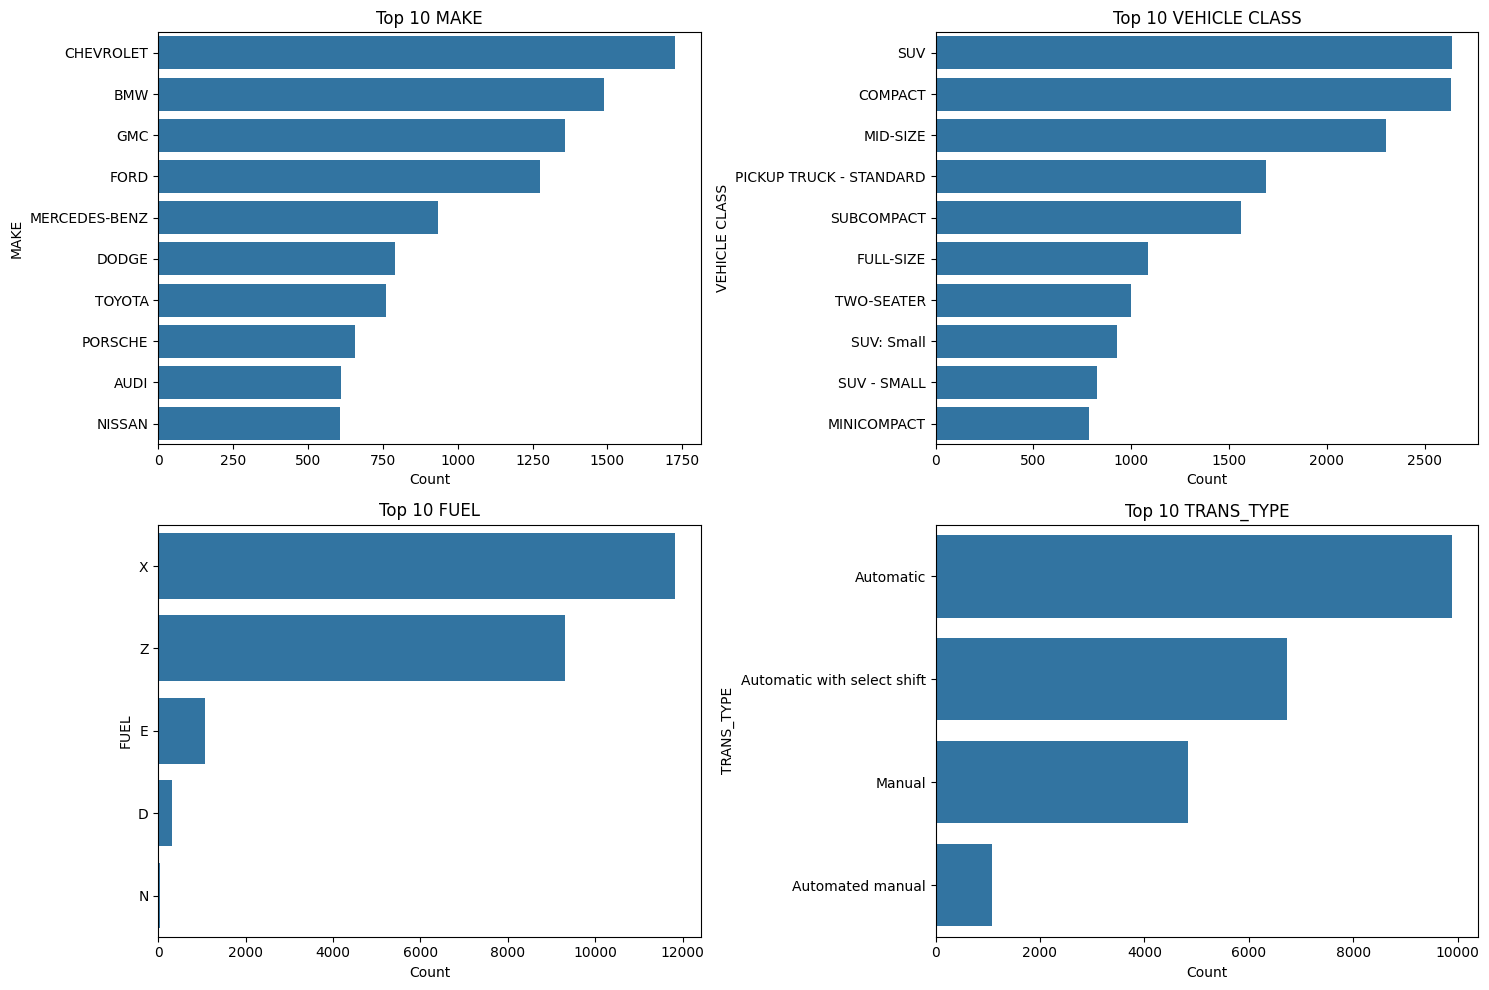

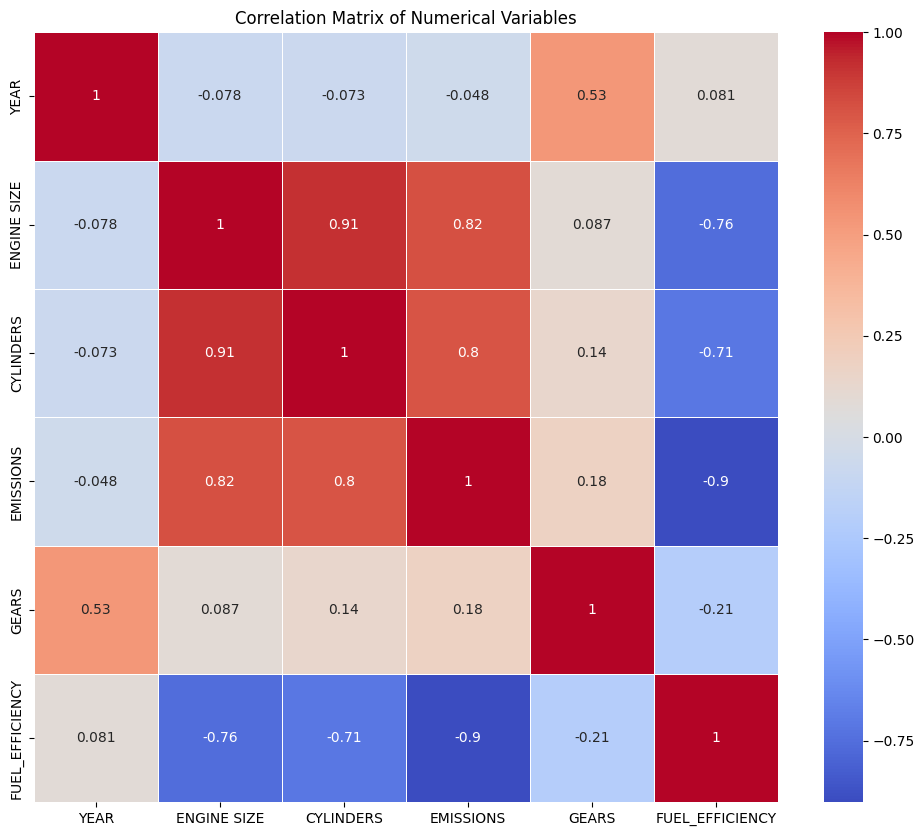

In [28]:
# Visualize the distribution of numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Visualize the distribution of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(data['FUEL_EFFICIENCY'], kde=True)
plt.title('Distribution of Fuel Efficiency (km/L)')
plt.xlabel('Fuel Efficiency (km/L)')
plt.ylabel('Frequency')
plt.show()

# Visualize categorical variables
categorical_cols = data.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    # Show only top 10 categories for better visualization
    top_categories = data[col].value_counts().nlargest(10)
    sns.barplot(x=top_categories.values, y=top_categories.index)
    plt.title(f'Top 10 {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Check correlations between numerical variables
plt.figure(figsize=(12, 10))
correlation_matrix = data[numerical_cols + ['FUEL_EFFICIENCY']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [29]:
print("Basic Statistics:")
print(data.describe())

Basic Statistics:
               YEAR   ENGINE SIZE     CYLINDERS     EMISSIONS  \
count  22556.000000  22556.000000  22556.000000  22556.000000   
mean    2011.554442      3.356646      5.854141    250.068452   
std        6.298269      1.335425      1.819597     59.355276   
min     2000.000000      0.800000      2.000000     83.000000   
25%     2006.000000      2.300000      4.000000    209.000000   
50%     2012.000000      3.000000      6.000000    243.000000   
75%     2017.000000      4.200000      8.000000    288.000000   
max     2022.000000      8.400000     16.000000    608.000000   

       FUEL_EFFICIENCY         GEARS  
count     22556.000000  22556.000000  
mean          9.697532      5.755231  
std           2.612082      1.823194  
min           3.831418      0.000000  
25%           7.874016      5.000000  
50%           9.433962      6.000000  
75%          10.989011      7.000000  
max          27.777778     10.000000  


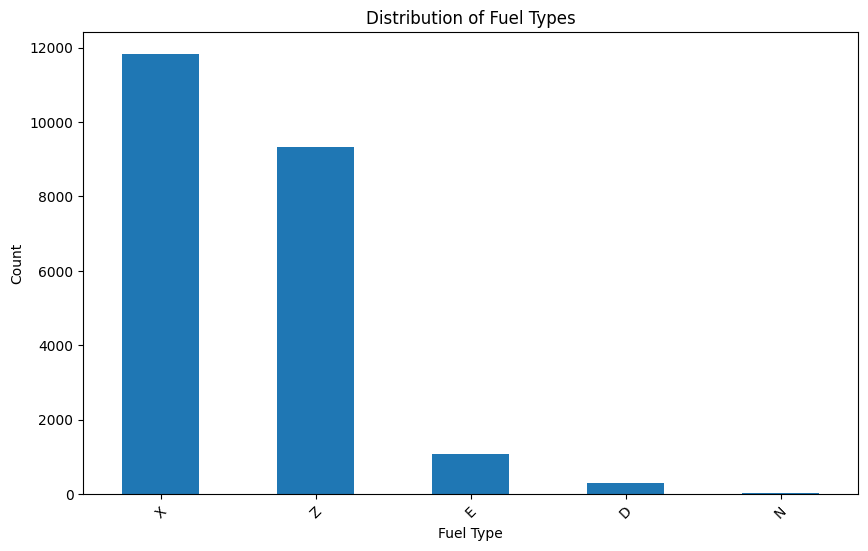

In [30]:
# Distribution of fuel types
plt.figure(figsize=(10, 6))
data['FUEL'].value_counts().plot.bar()
plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

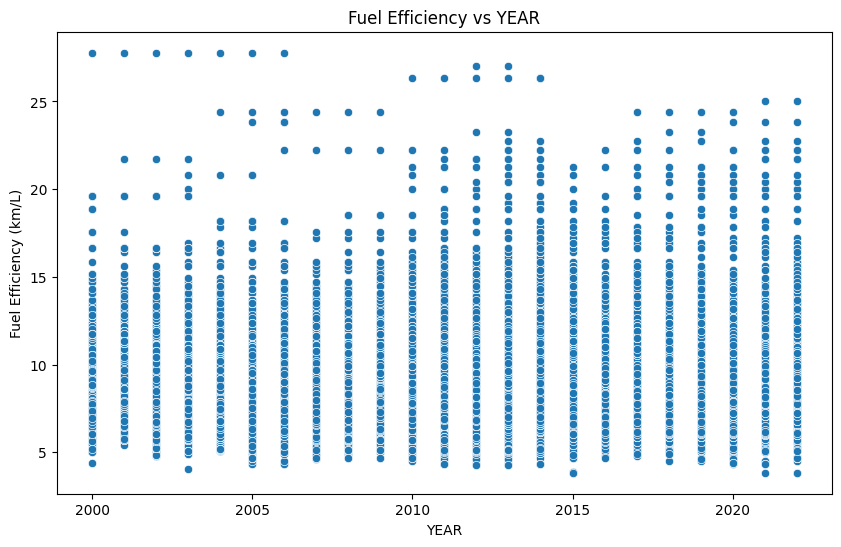

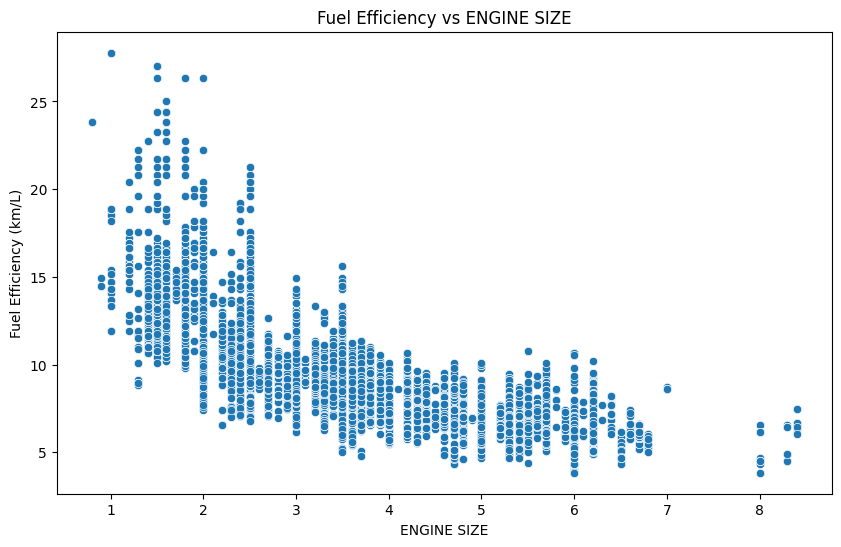

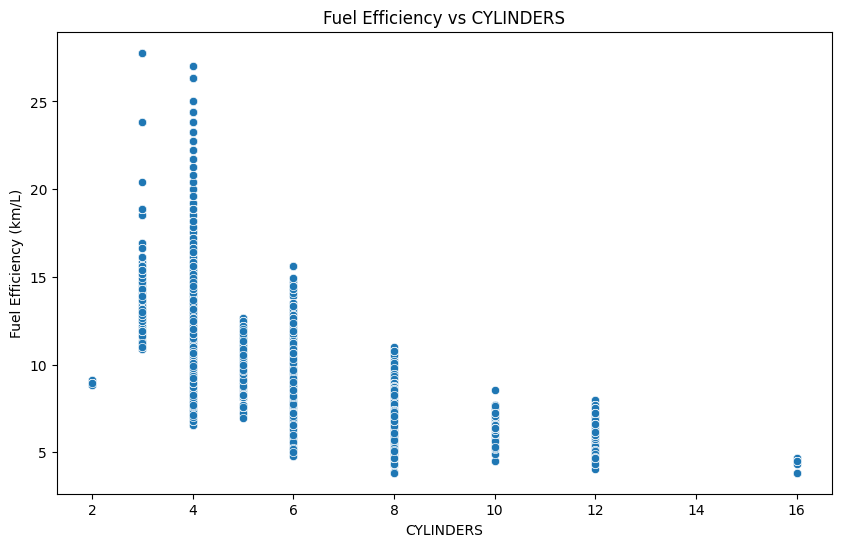

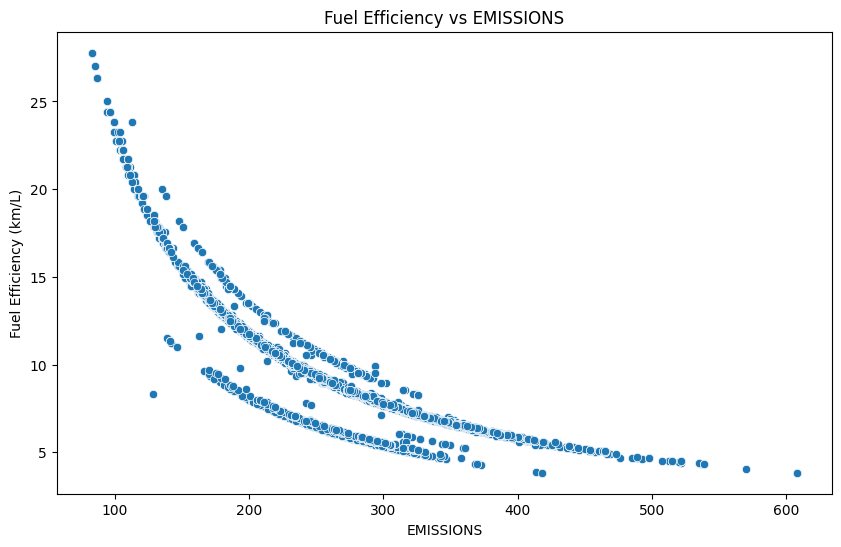

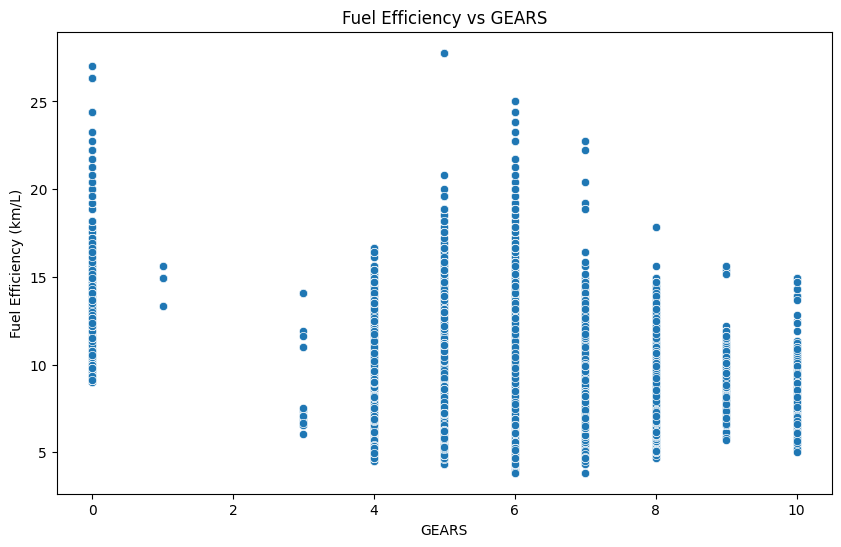

In [31]:
# Scatter plots of numerical variables against fuel efficiency
numeric_cols = data.select_dtypes(include=['number']).columns.drop('FUEL_EFFICIENCY')

for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=col, y='FUEL_EFFICIENCY')
    plt.xlabel(col)
    plt.ylabel('Fuel Efficiency (km/L)')
    plt.title(f"Fuel Efficiency vs {col}")
    plt.show()

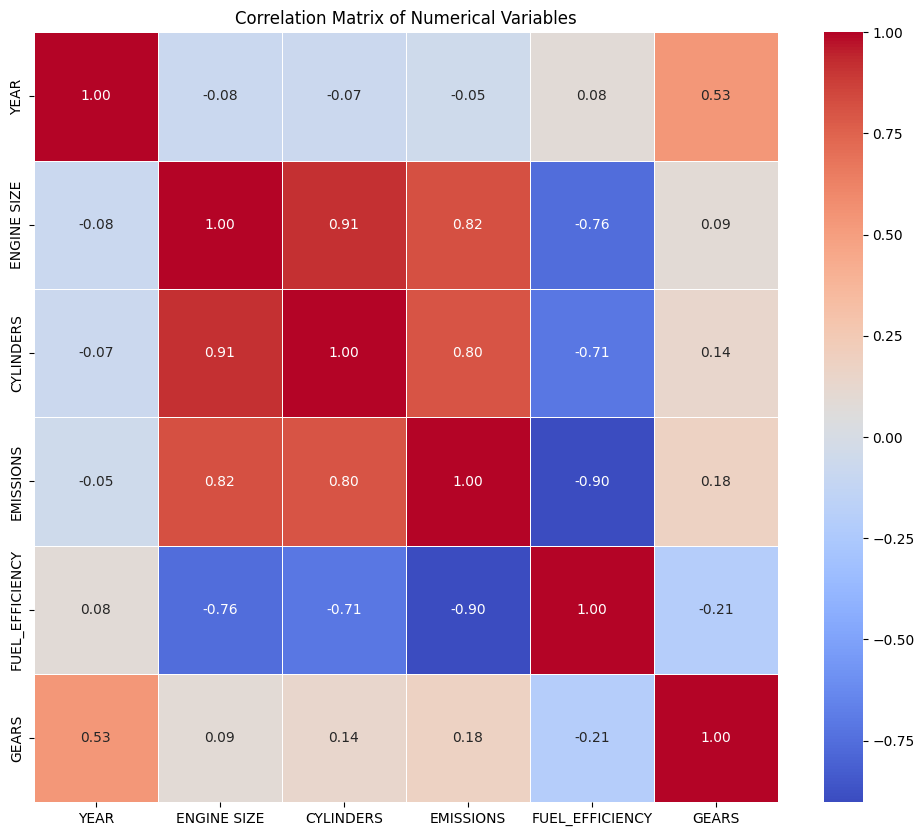

In [32]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
numeric_cols_all = data.select_dtypes(include=['number']).columns
corr_mat = data[numeric_cols_all].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

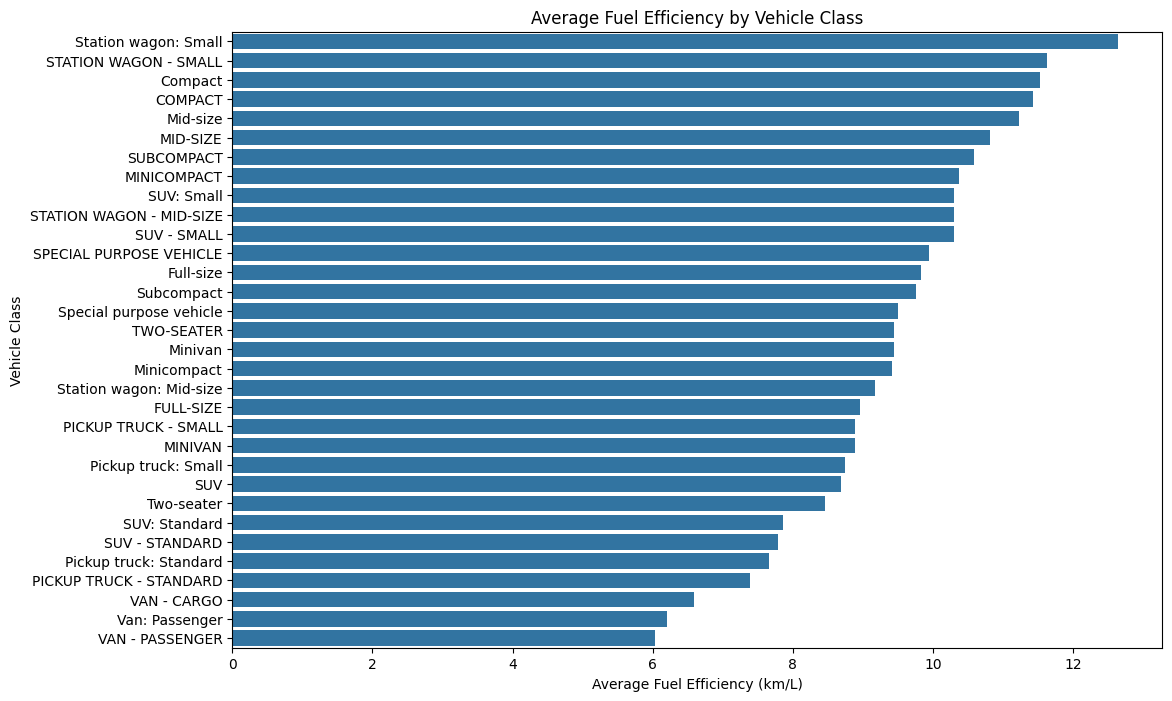

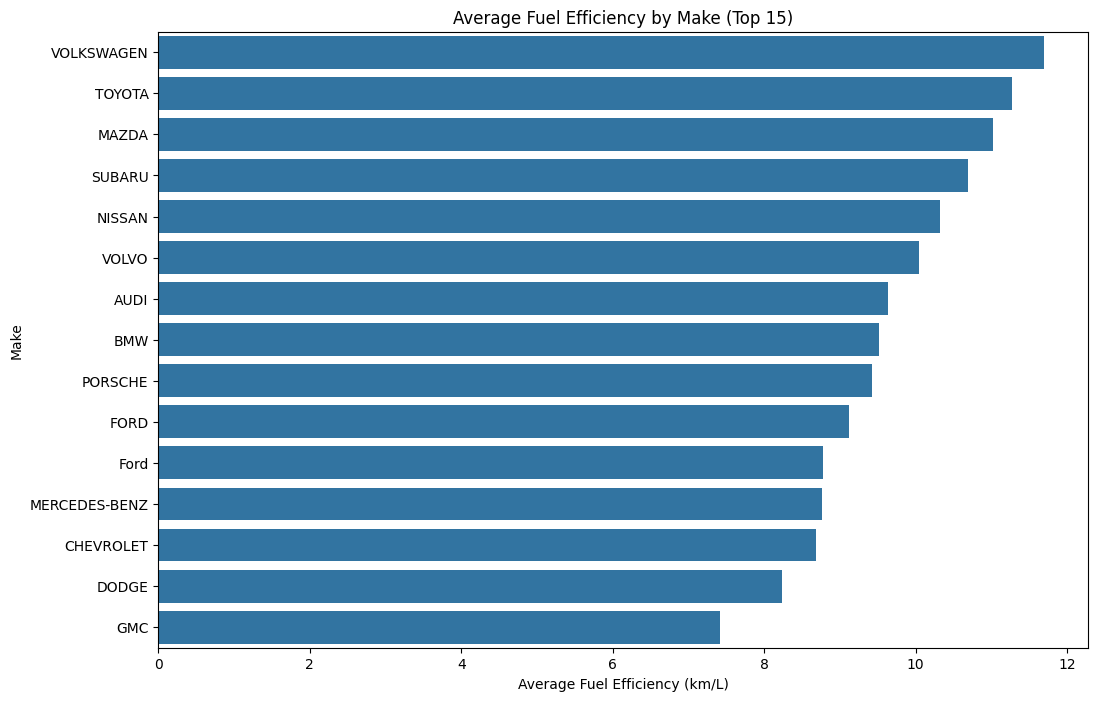

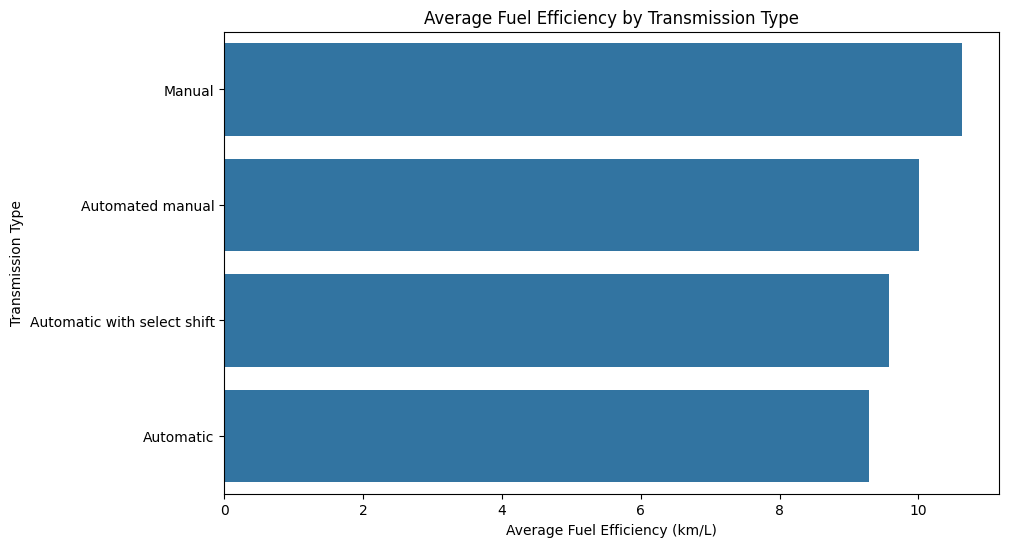

In [33]:
# Additional visualizations for categorical variables
# Vehicle Class vs Fuel Efficiency
plt.figure(figsize=(12, 8))
vehicle_class_efficiency = data.groupby('VEHICLE CLASS')['FUEL_EFFICIENCY'].mean().sort_values(ascending=False)
sns.barplot(x=vehicle_class_efficiency.values, y=vehicle_class_efficiency.index)
plt.title('Average Fuel Efficiency by Vehicle Class')
plt.xlabel('Average Fuel Efficiency (km/L)')
plt.ylabel('Vehicle Class')
plt.show()

# Make vs Fuel Efficiency (Top 15 makes)
plt.figure(figsize=(12, 8))
top_makes = data['MAKE'].value_counts().nlargest(15).index
make_efficiency = data[data['MAKE'].isin(top_makes)].groupby('MAKE')['FUEL_EFFICIENCY'].mean().sort_values(ascending=False)
sns.barplot(x=make_efficiency.values, y=make_efficiency.index)
plt.title('Average Fuel Efficiency by Make (Top 15)')
plt.xlabel('Average Fuel Efficiency (km/L)')
plt.ylabel('Make')
plt.show()

# Transmission Type vs Fuel Efficiency
plt.figure(figsize=(10, 6))
trans_efficiency = data.groupby('TRANS_TYPE')['FUEL_EFFICIENCY'].mean().sort_values(ascending=False)
sns.barplot(x=trans_efficiency.values, y=trans_efficiency.index)
plt.title('Average Fuel Efficiency by Transmission Type')
plt.xlabel('Average Fuel Efficiency (km/L)')
plt.ylabel('Transmission Type')
plt.show()

<Figure size 1200x1000 with 0 Axes>

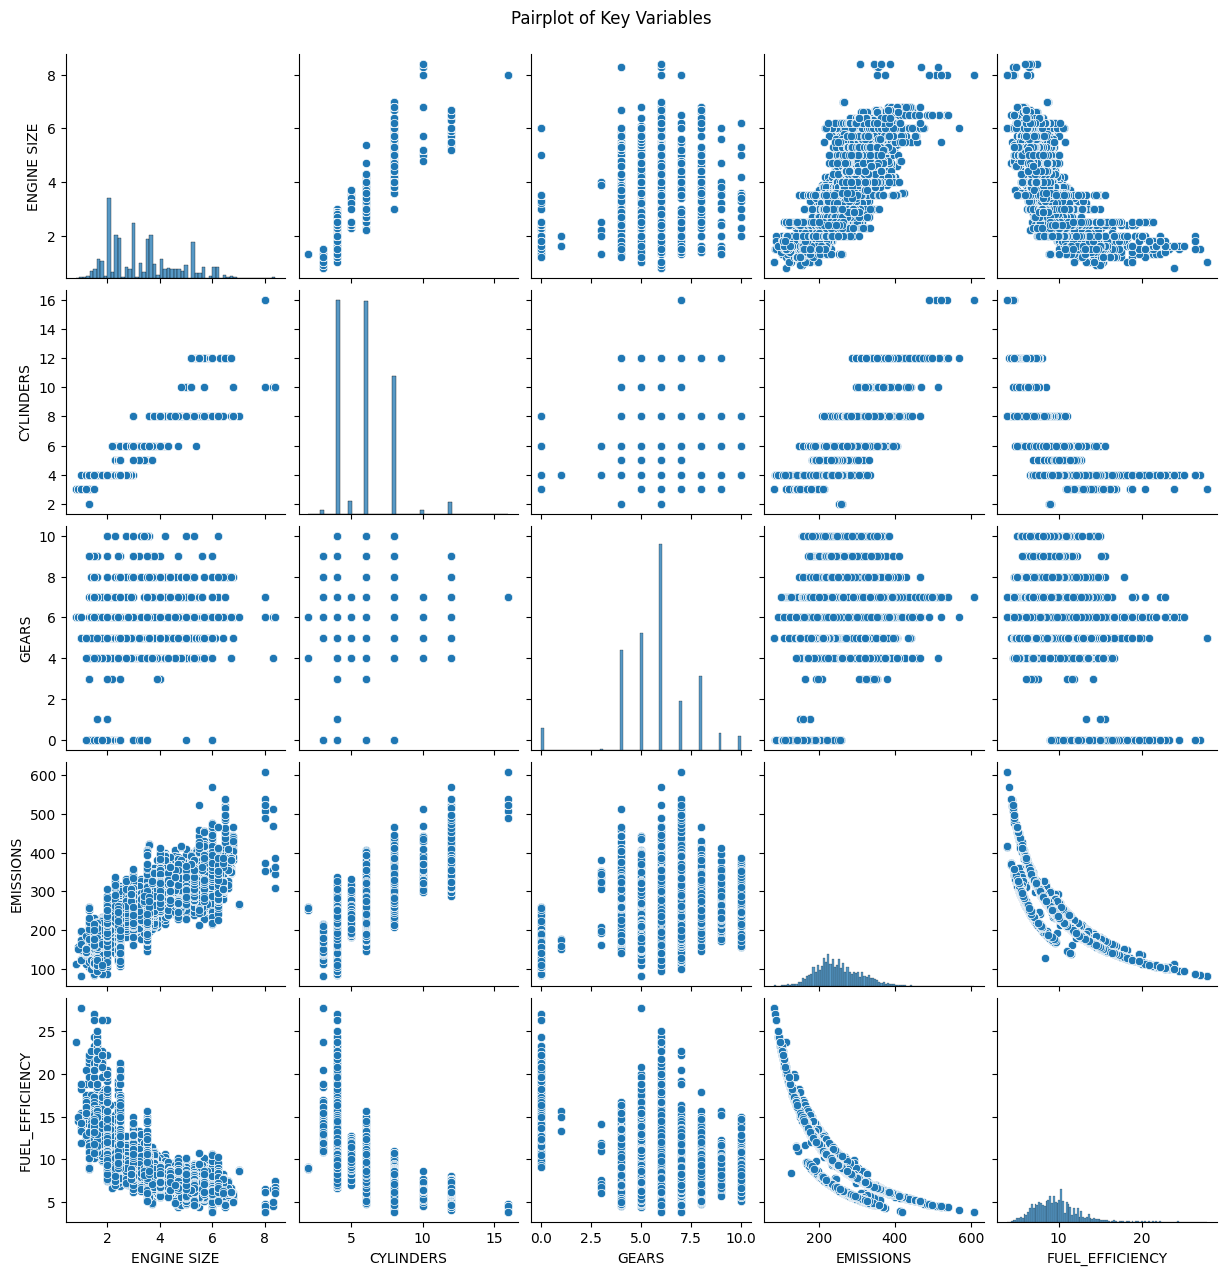

In [34]:
# Pairplot for key numerical variables
key_vars = ['ENGINE SIZE', 'CYLINDERS', 'GEARS', 'EMISSIONS', 'FUEL_EFFICIENCY']
plt.figure(figsize=(12, 10))
sns.pairplot(data[key_vars])
plt.suptitle('Pairplot of Key Variables', y=1.02)
plt.show()

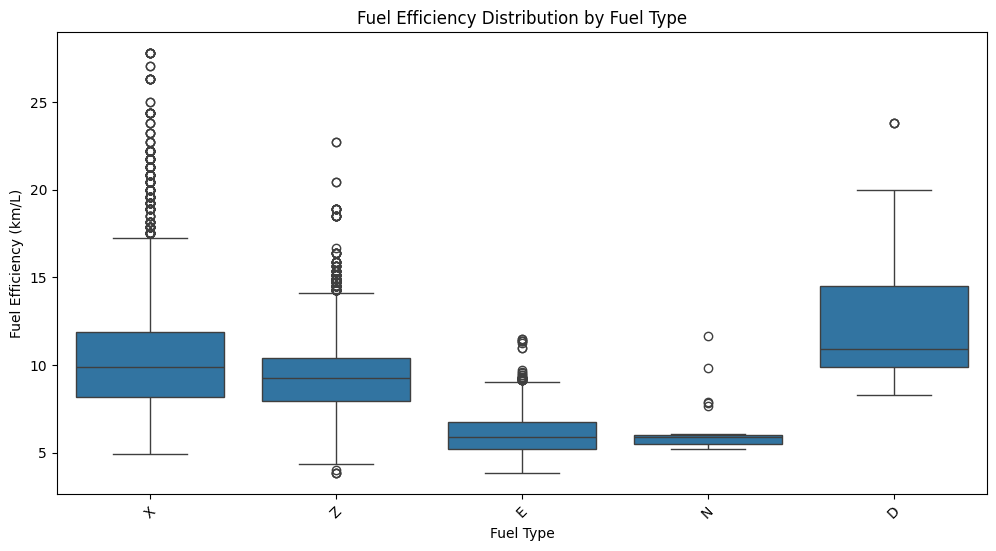

In [35]:

# Fuel Efficiency distribution by Fuel Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='FUEL', y='FUEL_EFFICIENCY')
plt.title('Fuel Efficiency Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Fuel Efficiency (km/L)')
plt.xticks(rotation=45)
plt.show()

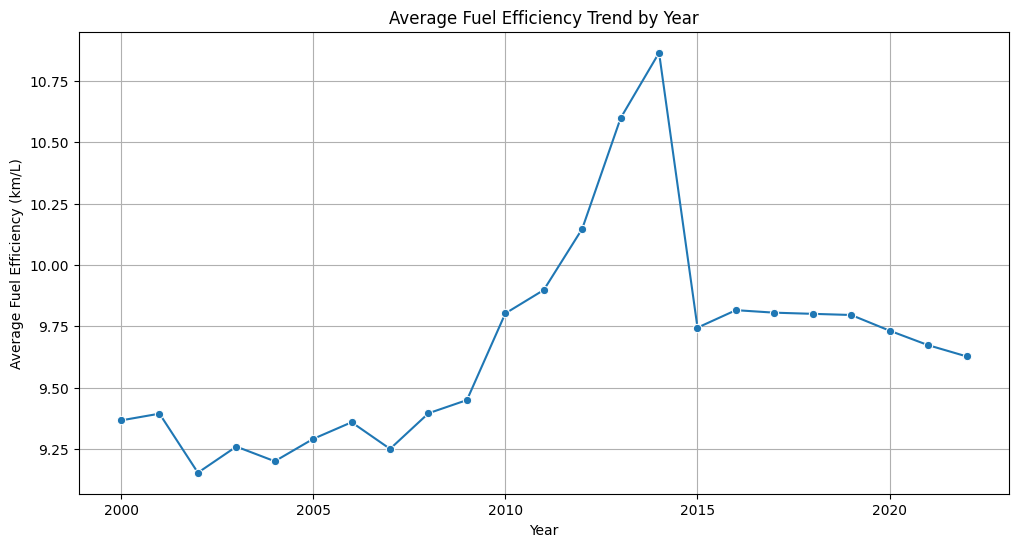

In [36]:
# Year vs Fuel Efficiency trend
plt.figure(figsize=(12, 6))
year_efficiency = data.groupby('YEAR')['FUEL_EFFICIENCY'].mean()
sns.lineplot(x=year_efficiency.index, y=year_efficiency.values, marker='o')
plt.title('Average Fuel Efficiency Trend by Year')
plt.xlabel('Year')
plt.ylabel('Average Fuel Efficiency (km/L)')
plt.grid(True)
plt.show()

## data preprocessing

In [37]:
print(data.columns)

# Separate features and target
X = data.drop('FUEL_EFFICIENCY', axis=1)  
y = data['FUEL_EFFICIENCY'] 

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical columns (to be one-hot encoded):", categorical_cols)
print("Numerical columns (to be scaled):", numerical_cols)

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)
feature_names = numerical_cols.copy()

# For categorical features, get the one-hot encoded feature names
for col in categorical_cols:
    categories = preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[categorical_cols.index(col)]
    for category in categories:
        feature_names.append(f"{col}_{category}")

# Create a DataFrame with the processed data
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("\nProcessed data shape:", X_processed_df.shape)
print("First 5 rows of processed data:")
print(X_processed_df.head())

# Split the data into training and testing sets (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42
)


print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Save the processed data
X_train.to_csv('./train/X_train.csv', index=False)
X_test.to_csv('./train/X_test.csv', index=False)
y_train.to_csv('./train/y_train.csv', index=False)
y_test.to_csv('./train/y_test.csv', index=False)

# Save the preprocessor for later use
import joblib
joblib.dump(preprocessor, './train/preprocessor.joblib')

print("\nData preprocessing completed and saved.")

# Display the final columns
print("\nFinal feature columns (first 20):")
print(X_processed_df.columns.tolist()[:20])
print("...")
print(f"Total features: {len(X_processed_df.columns)}")

Index(['YEAR', 'MAKE', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS', 'FUEL',
       'EMISSIONS', 'FUEL_EFFICIENCY', 'GEARS', 'TRANS_TYPE'],
      dtype='object')

Categorical columns (to be one-hot encoded): ['MAKE', 'VEHICLE CLASS', 'FUEL', 'TRANS_TYPE']
Numerical columns (to be scaled): ['YEAR', 'ENGINE SIZE', 'CYLINDERS', 'EMISSIONS', 'GEARS']

Processed data shape: (22556, 133)
First 5 rows of processed data:
       YEAR  ENGINE SIZE  CYLINDERS  EMISSIONS     GEARS  MAKE_ACURA  \
0 -1.834583    -1.315450  -1.019007  -1.079430 -0.962745         1.0   
1 -1.834583    -1.315450  -1.019007  -1.264759 -0.414245         1.0   
2 -1.834583    -0.117303   0.080162  -0.338115 -0.414245         1.0   
3 -1.834583     0.107350   0.080162   0.234720 -0.962745         1.0   
4 -1.834583    -1.165681  -1.019007  -0.877253 -0.962745         1.0   

   MAKE_ALFA ROMEO  MAKE_ASTON MARTIN  MAKE_AUDI  MAKE_Acura  ...  \
0              0.0                0.0        0.0         0.0  ...   
1            

## building models

In [38]:
# Load the processed data
X_train = pd.read_csv('train/X_train.csv')
X_test = pd.read_csv('train/X_test.csv')
y_train = pd.read_csv('train/y_train.csv')
y_test = pd.read_csv('train/y_test.csv')

# Convert to Series if they are DataFrames with single column
y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

# Load the preprocessor
preprocessor = joblib.load('train/preprocessor.joblib')

# Model Development

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [39]:
print("\n=== MODEL EVALUATION ===")

# Calculate metrics for training set
train_mse = mean_squared_error(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

# Calculate metrics for test set
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

# better format
print(f"MSE  : {train_mse:.4f}")      # the less the better
print(f"MAE  : {train_mae:.4f}")      # average absolute error
print(f"RMSE : {train_rmse:.4f}")     # root mean square error
print(f"R²   : {train_r2:.4f}")       # the closer to 1 the better


=== MODEL EVALUATION ===
MSE  : 0.5564
MAE  : 0.4598
RMSE : 0.7459
R²   : 0.9186


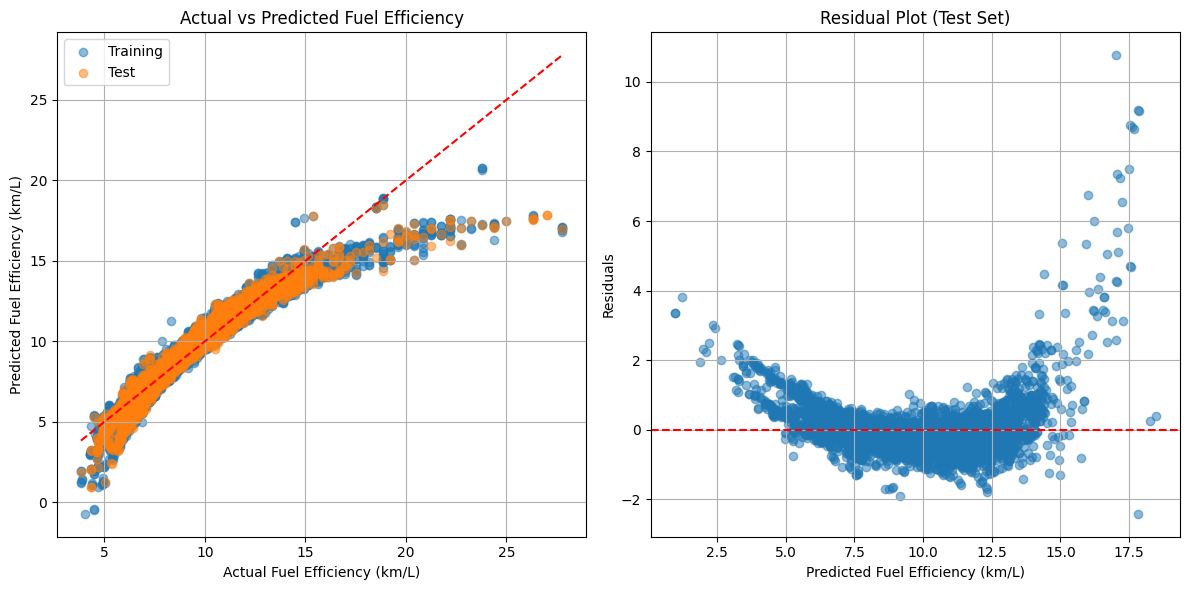

In [40]:
# Actual vs Predicted values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5, label='Training')
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Test')
plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 'r--')
plt.xlabel('Actual Fuel Efficiency (km/L)')
plt.ylabel('Predicted Fuel Efficiency (km/L)')
plt.title('Actual vs Predicted Fuel Efficiency')
plt.legend()
plt.grid(True)

# Residuals plot
plt.subplot(1, 2, 2)
residuals_test = y_test - y_pred_test
plt.scatter(y_pred_test, residuals_test, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Fuel Efficiency (km/L)')
plt.ylabel('Residuals')
plt.title('Residual Plot (Test Set)')
plt.grid(True)

plt.tight_layout()
plt.show()


=== FEATURE IMPORTANCE ===
Top 15 Most Important Features:
                           Feature  Coefficient  Abs_Coefficient
18                    MAKE_Bugatti     5.294207         5.294207
15                    MAKE_BUGATTI     4.076328         4.076328
81                      MAKE_SMART     3.359038         3.359038
125                         FUEL_E    -2.484967         2.484967
124                         FUEL_D     2.456018         2.456018
3                        EMISSIONS    -2.407662         2.407662
29                    MAKE_FERRARI     2.065160         2.065160
54                MAKE_Lamborghini     1.869747         1.869747
50                MAKE_LAMBORGHINI     1.338287         1.338287
13                    MAKE_BENTLEY     1.266437         1.266437
77                MAKE_Rolls-Royce     1.167706         1.167706
123   VEHICLE CLASS_Van: Passenger     1.091156         1.091156
122  VEHICLE CLASS_VAN - PASSENGER     0.916934         0.916934
126                         FU

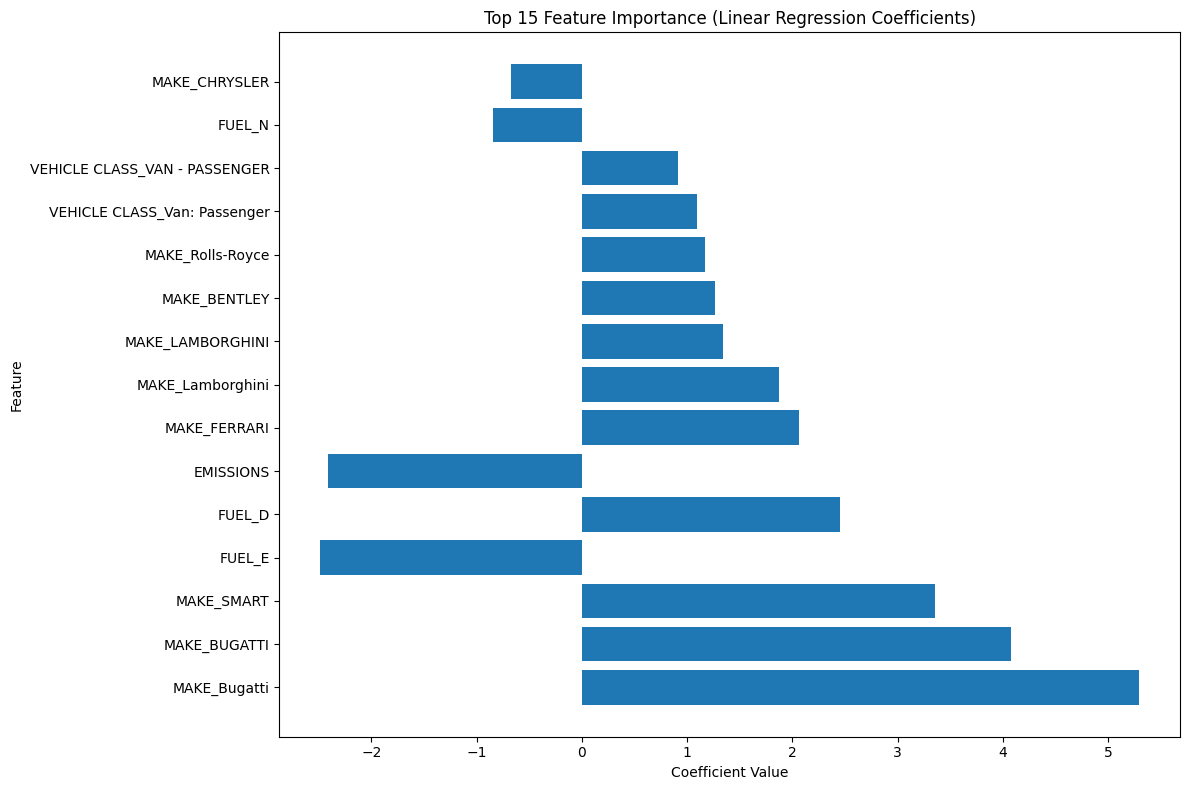

In [41]:
# 5. Feature importance analysis
print("\n=== FEATURE IMPORTANCE ===")

# Get the coefficients
coefficients = model.coef_

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute value of coefficients
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Display top 15 features
print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance (Linear Regression Coefficients)')
plt.tight_layout()
plt.show()

In [42]:
# 6. Save the model
joblib.dump(model, 'model/linear_regression_model.joblib')
print("\nModel saved as 'linear_regression_model.joblib'")

# 7. Make predictions on new sample data (for demonstration)
print("\n=== SAMPLE PREDICTIONS ===")

# Get a few sample rows from the original data
sample_indices = [10, 20, 30, 40, 50]
sample_data = data.iloc[sample_indices].copy()

# Separate features and target
X_sample = sample_data.drop('FUEL_EFFICIENCY', axis=1)
y_sample_actual = sample_data['FUEL_EFFICIENCY']

# Preprocess the sample data
X_sample_processed = preprocessor.transform(X_sample)

# Make predictions
y_sample_pred = model.predict(X_sample_processed)

# Display results
print("\nSample Predictions:")
for i, idx in enumerate(sample_indices):
    print(f"Sample {i+1}:")
    print(f"  Actual: {y_sample_actual.iloc[i]:.2f} km/L")
    print(f"  Predicted: {y_sample_pred[i]:.2f} km/L")
    print(f"  Difference: {abs(y_sample_actual.iloc[i] - y_sample_pred[i]):.2f} km/L")
    print()

# 8. Model Summary
print("\n=== MODEL SUMMARY ===")
print(f"Model: Linear Regression")
print(f"Features: {X_train.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f} km/L")

# Interpretation of results
print("\n=== INTERPRETATION ===")
print("The model's performance:")
print(f"- R² of {test_r2:.4f} means that {test_r2*100:.1f}% of the variability in fuel efficiency")
print("  can be explained by the features in the model.")
print(f"- RMSE of {test_rmse:.4f} km/L means that, on average, the model's predictions")
print("  are off by approximately this value in terms of fuel efficiency.")
print("\nMost important features affecting fuel efficiency:")
for i, row in feature_importance.head(5).iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    effect = "increases" if coef > 0 else "decreases"
    print(f"- {feature}: {effect} fuel efficiency")


Model saved as 'linear_regression_model.joblib'

=== SAMPLE PREDICTIONS ===

Sample Predictions:
Sample 1:
  Actual: 11.90 km/L
  Predicted: 11.70 km/L
  Difference: 0.20 km/L

Sample 2:
  Actual: 8.62 km/L
  Predicted: 8.57 km/L
  Difference: 0.05 km/L

Sample 3:
  Actual: 10.20 km/L
  Predicted: 10.22 km/L
  Difference: 0.02 km/L

Sample 4:
  Actual: 10.31 km/L
  Predicted: 10.61 km/L
  Difference: 0.30 km/L

Sample 5:
  Actual: 6.94 km/L
  Predicted: 6.25 km/L
  Difference: 0.70 km/L


=== MODEL SUMMARY ===
Model: Linear Regression
Features: 133
Training Samples: 18044
Test Samples: 4512
Test R²: 0.9107
Test RMSE: 0.7781 km/L

=== INTERPRETATION ===
The model's performance:
- R² of 0.9107 means that 91.1% of the variability in fuel efficiency
  can be explained by the features in the model.
- RMSE of 0.7781 km/L means that, on average, the model's predictions
  are off by approximately this value in terms of fuel efficiency.

Most important features affecting fuel efficiency:
- MAK

c:\Users\Malv\Downloads\class\ai lab\ai-venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
